# Anime Dataset - Data Exploration

**Author:** Alexei Luchian  
**Date:** October 2025  
**Goal:** Explore the scraped anime dataset and understand its structure

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import ast

sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)
pd.set_option('display.max_columns', None)

print("Libraries imported successfully!")

Libraries imported successfully!


## 1. Load the Data

In [2]:
df = pd.read_csv('../data/raw/anime_dataset.csv')
print(f"Dataset loaded successfully! Shape: {df.shape}")

Dataset loaded successfully! Shape: (1050, 9)


In [3]:
df.head()

,title,score,genres,episodes,synopsis,popularity,members,studios,year
0,Attack on Titan,8.57,"['Action', 'Award Winning', 'Drama', 'Suspense...",25.0,"Centuries ago, mankind was slaughtered to near...",1,4245518,['Wit Studio'],2013.0
1,Death Note,8.62,"['Supernatural', 'Suspense', 'Psychological', ...",37.0,"Brutal murders, petty thefts, and senseless vi...",2,4186098,['Madhouse'],2006.0
2,Fullmetal Alchemist: Brotherhood,9.10,"['Action', 'Adventure', 'Drama', 'Fantasy', 'M...",64.0,After a horrific alchemy experiment goes wrong...,3,3588803,['Bones'],2009.0
3,One-Punch Man,8.48,"['Action', 'Comedy', 'Adult Cast', 'Parody', '...",12.0,The seemingly unimpressive Saitama has a rathe...,4,3443899,['Madhouse'],2015.0
4,Demon Slayer: Kimetsu no Yaiba,8.42,"['Action', 'Award Winning', 'Supernatural', 'H...",26.0,"Ever since the death of his father, the burden...",5,3340293,['ufotable'],2019.0


## 2. Data Overview

In [4]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1050 entries, 0 to 1049
Data columns (total 9 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   title       1050 non-null   object 
 1   score       1050 non-null   float64
 2   genres      1050 non-null   object 
 3   episodes    1047 non-null   float64
 4   synopsis    1050 non-null   object 
 5   popularity  1050 non-null   int64  
 6   members     1050 non-null   int64  
 7   studios     1050 non-null   object 
 8   year        882 non-null    float64
dtypes: float64(3), int64(2), object(4)
memory usage: 74.0+ KB
None


In [5]:
df.describe()

,score,episodes,popularity,members,year
count,1050.000000,1047.000000,1050.000000,1.050000e+03,882.000000
mean,7.678733,18.103152,525.499048,6.887306e+05,2015.184807
std,0.667837,31.457198,303.251925,5.522504e+05,6.261505
min,5.080000,1.000000,1.000000,2.604740e+05,1986.000000
25%,7.252500,12.000000,263.250000,3.405882e+05,2012.000000
50%,7.730000,12.000000,525.500000,4.775560e+05,2016.000000
75%,8.170000,13.500000,787.750000,8.148055e+05,2020.000000
max,9.290000,500.000000,1050.000000,4.245518e+06,2025.000000


## 3. Data Visualization

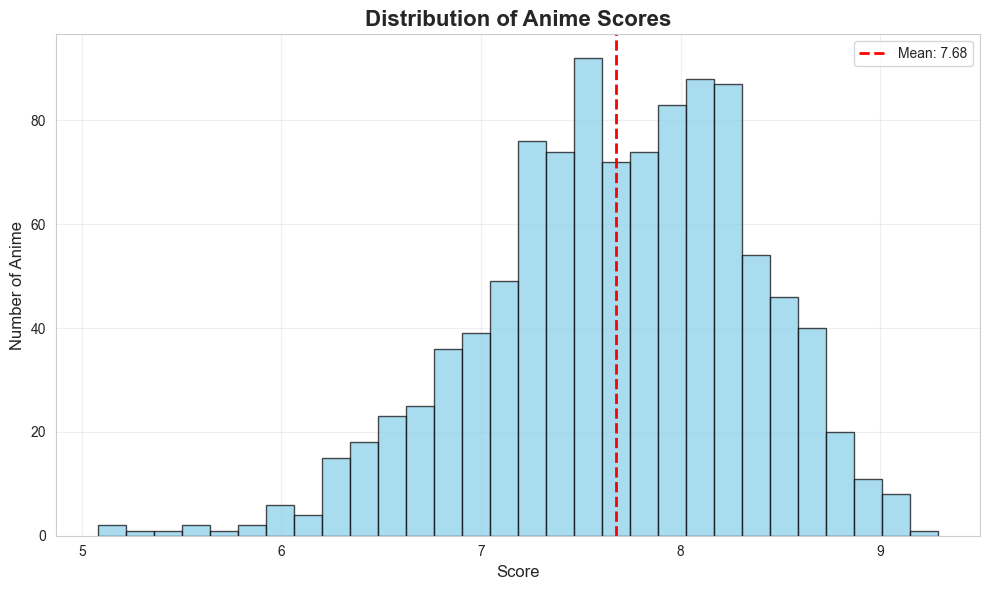

Chart saved to ../data/visualizations/score_distribution.png


In [6]:
plt.figure(figsize=(10, 6))
plt.hist(df['score'], bins=30, edgecolor='black', color='skyblue', alpha=0.7)
mean_score = df['score'].mean()
plt.axvline(mean_score, color='red', linestyle='--', linewidth=2, 
            label=f'Mean: {mean_score:.2f}')

plt.title('Distribution of Anime Scores', fontsize=16, fontweight='bold')
plt.xlabel('Score', fontsize=12)
plt.ylabel('Number of Anime', fontsize=12)
plt.legend()
plt.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('../data/visualizations/score_distribution.png', dpi=300, bbox_inches='tight')
plt.show()

print("Chart saved to ../data/visualizations/score_distribution.png")

### Observations:
- After extending the database to 1050, most anime scores are still between 7.5 and 8.5
- The more we extend the database, the more animes have lower scores 

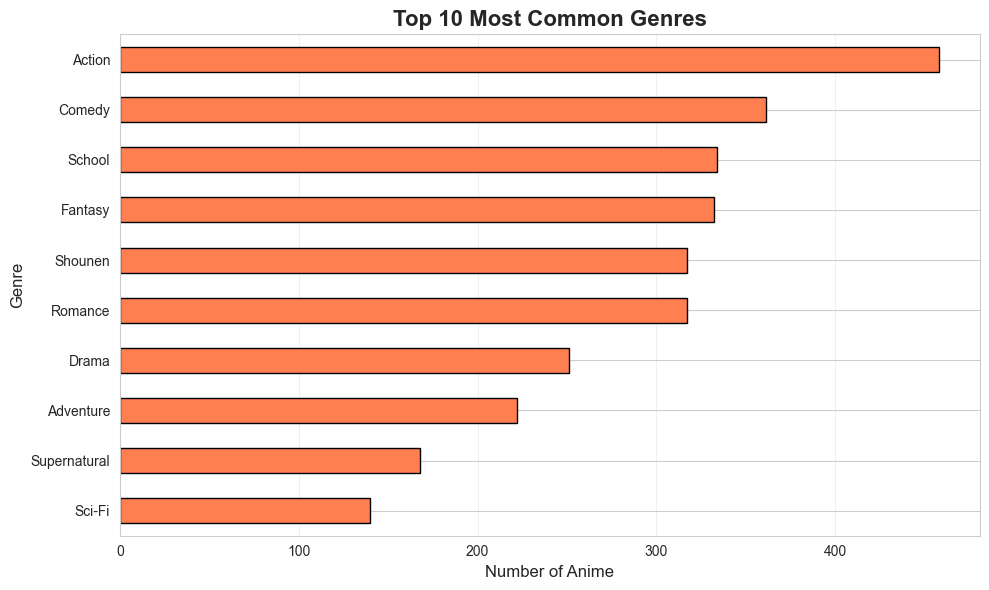

Found 76 unique genres
Chart saved!


In [7]:
df['genres'] = df['genres'].apply(ast.literal_eval)

all_genres = []
for genres_list in df['genres']:
    all_genres.extend(genres_list)

genre_counts = pd.Series(all_genres).value_counts().head(10)

plt.figure(figsize=(10,6))
genre_counts.plot(kind='barh', color='coral', edgecolor='black')
plt.title('Top 10 Most Common Genres', fontsize=16, fontweight='bold')
plt.xlabel('Number of Anime', fontsize=12)
plt.ylabel('Genre', fontsize=12)
plt.gca().invert_yaxis()
plt.grid(alpha=0.3, axis='x')
plt.tight_layout()
plt.savefig('../data/visualizations/top_genres.png', dpi=300, bbox_inches='tight')
plt.show()

print(f"Found {len(set(all_genres))} unique genres")
print("Chart saved!")

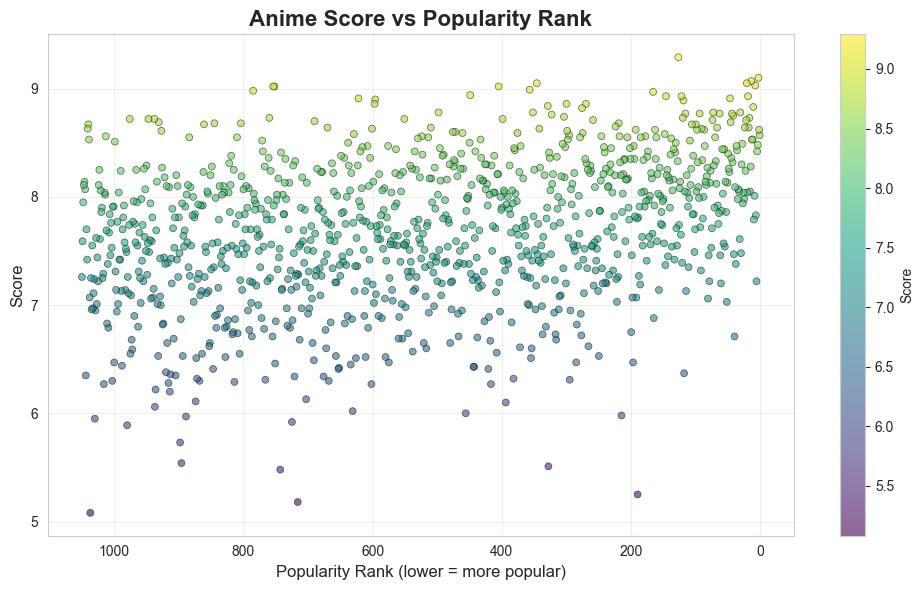

In [10]:
plt.figure(figsize=(10, 6))

scatter = plt.scatter(df['popularity'], df['score'],
                      c=df['score'], cmap='viridis',
                      alpha=0.6, s=25, edgecolors='black', linewidth=0.5)

plt.colorbar(scatter, label="Score")

plt.title('Anime Score vs Popularity Rank', fontsize=16, fontweight='bold')
plt.xlabel('Popularity Rank (lower = more popular)', fontsize=12)
plt.ylabel('Score', fontsize=12)
plt.gca().invert_xaxis()  # More popular on the right
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('../data/visualizations/score_vs_popularity.png', dpi=300, bbox_inches='tight')
plt.show()

## 4. Summary

### Key Findings:
1. **Dataset Size:** All 1050 animes were scraped successfully.
2. **Score Distribution:** Mean score of 7.68, something expected since we added more animes with a lower score. most anime are still rated 7.5-8.5.
3. **Top Genres:** At this stage Action is still at the top, but Comedy is catching up. 
4. **Quality vs Popularity:** After the changes we can see some sort of a pattern on the plot, which shows that generally, animes that are more popular have a higher score and vice versa.

In [9]:
df.to_csv('../data/processed/anime_clean.csv', index=False)
print("Cleaned data saved to ../data/processed/anime_clean.csv")

Cleaned data saved to ../data/processed/anime_clean.csv
